# Detecting misclassifications on sensor-based activity recognition

A model that classifies a wearer's activity from body-worn sensors
is wrong sometimes -- the question is whether it *knows* it. This
example wraps a GRU trained on the UCI Daily and Sports Activities
dataset (19 activities, 5 body-worn Xsens units, 45 sensor channels
per 5-second window) and compares two safetycage methods around it:
**MSP**, which only needs class probabilities, and **SPARDACUS**,
which reads hidden-layer activations.

| File | Class | What it declares |
| --- | --- | --- |
| `activity_datamodule.py` | `ActivityDataModule` | how data is loaded, transformed and split |
| `gru.py` | `GRUActivityClassifier` | the GRU + linear head classifying each window |

There is no hand-written `ModelModule` this time: the generic
`TorchModelModule`, given `selected_layers`, is enough for both MSP
and SPARDACUS.

## Setup

`fix_pythonpath_if_working_locally` points `import safetycage` at this
repository's `src/` rather than any released version you may have
installed, so the notebook exercises the working tree.

In [1]:
import sys

sys.path.insert(0, '..')  # examples/, where utils.py lives
from utils import fix_pythonpath_if_working_locally

# Imported here rather than in the first plotting cell: IPython registers
# the inline backend's PNG formatter as a side effect of the first pyplot
# import, too late to capture figures shown in that same cell.
import matplotlib.pyplot as plt
import numpy as np

print('safetycage source:', fix_pythonpath_if_working_locally())

safetycage source: /Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src


## Load data

This dataset ships with no official train/test split, so we carve
one out ourselves -- and, to guarantee no leakage between fitting
the model and fitting the cage, we split the *whole* dataset in two
first: one half trains and evaluates the GRU, the other trains and
evaluates the safety cage. Neither half ever sees the other's data.

The activities in this dataset are almost perfectly separable from
clean sensor readings -- a GRU trained on the raw data reaches >97%
test accuracy, leaving too few errors per class for either method
below to have much to work with. To keep this a genuine
misclassification-detection problem, we add fixed Gaussian noise to
every window once, up front, simulating a noisier real-world sensor
-- not per-epoch augmentation, just a harder fixed dataset.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from activity_datamodule import ActivityDataModule, load_raw_activity_data, DEFAULT_DATA_DIR, ACTIVITIES

DEVICE = 'cpu'
NOISE_STD = 0

x, y = load_raw_activity_data(DEFAULT_DATA_DIR)
x = x + NOISE_STD * np.random.RandomState(42).standard_normal(x.shape).astype(np.float32)

x_model, x_cage, y_model, y_cage = train_test_split(
    x, y, test_size=0.5, random_state=42, stratify=y
)

def train_val_test_split(x, y, val_size=0.15, test_size=0.15, random_state=42):
    """Stratified three-way split of (x, y)."""
    x_train, x_temp, y_train, y_temp = train_test_split(
        x, y, test_size=val_size + test_size, random_state=random_state, stratify=y
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=test_size / (val_size + test_size),
        random_state=random_state, stratify=y_temp,
    )
    return x_train, y_train, x_val, y_val, x_test, y_test

x_model_train, y_model_train, x_model_val, y_model_val, x_model_test, y_model_test = (
    train_val_test_split(x_model, y_model)
)

data_module_model = ActivityDataModule(
    x_train=x_model_train, y_train=y_model_train,
    x_val=x_model_val, y_val=y_model_val,
    x_test=x_model_test, y_test=y_model_test,
    device=DEVICE,
)
data_module_model.print_partition_summary()


train x=(3192, 125, 45) y=(3192,)
val   x=(684, 125, 45) y=(684,)
test  x=(684, 125, 45) y=(684,)


45 channels of acceleration, angular velocity and magnetic field per
timestep are not exactly intuitive to look at as numbers. As a sanity
check, here is one window's raw channels plotted over time, one
subplot per sensor unit -- e.g. for a cycling window, the legs show a
clear ~1.3s-period oscillation matching a pedaling cadence, directly in
the raw accelerometer signal.

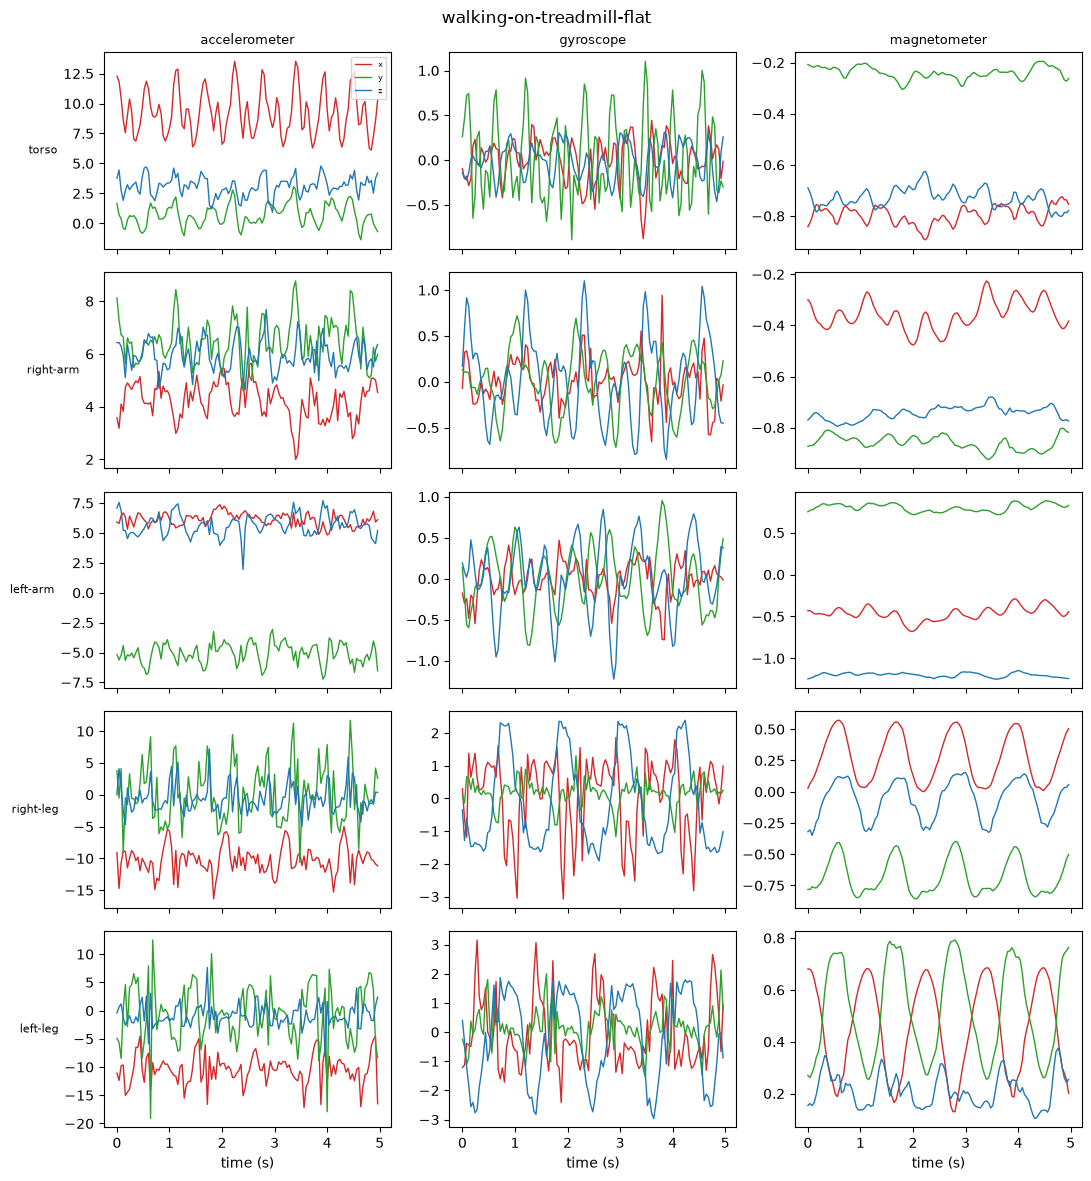

In [3]:
walking_idx = ACTIVITIES.index('walking-on-treadmill-flat')
sample_idx = int(np.where(y_model_train == walking_idx)[0][0])

data_module_model.plot_window_timeseries(index=sample_idx, split='train')

## The model

Each window is a (125 timestep, 45 channel) sequence, so a GRU reads
it timestep by timestep and its final hidden state summarizes the
whole window. A `BatchNorm1d` on that hidden state is the model's
internal normalization; a small linear head then classifies it.

The GRU module itself is never a `selected_layers` target: its
forward returns a `(output, h_n)` tuple, not a plain tensor, which is
not what `TorchModelModule`'s activation hook expects. `relu`, in the
head, is a plain 2D tensor and hooks cleanly.

In [4]:
import os
import torch
from gru import GRUActivityClassifier

model = GRUActivityClassifier(num_classes=data_module_model.num_classes, hidden_size=32)

CHECKPOINT = './gru_activity.pt'
if os.path.exists(CHECKPOINT):
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

model.to(DEVICE)

GRUActivityClassifier(
  (gru): GRU(45, 32, batch_first=True)
  (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=19, bias=True)
)

## Training the GRU

Ordinary PyTorch, nothing safetycage-specific. The model outputs raw
logits (the usual torch convention), so the loss is plain
`CrossEntropyLoss`.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from torch import nn

def as_loader(split, batch_size, shuffle=False, device='cpu'):
    """Wrap an (x, y) numpy split as a DataLoader."""
    x, y = split
    return DataLoader(
        TensorDataset(torch.from_numpy(x).float().to(device), torch.from_numpy(y).long().to(device)),
        batch_size=batch_size,
        shuffle=shuffle,
    )

epochs = 10
batch_size = 32
learning_rate = 1e-3

train_loader = as_loader(data_module_model.data_train, batch_size, shuffle=True, device=DEVICE)
val_loader = as_loader(data_module_model.data_val, batch_size, device=DEVICE)
test_loader = as_loader(data_module_model.data_test, batch_size, device=DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()


@torch.no_grad()
def evaluate(model, loader, device='cpu'):
    """Return (mean loss, accuracy) over a loader."""
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)

        total_loss += loss_fn(logits, y).item() * len(y)
        correct += (logits.argmax(dim=1) == y).sum().item()
        seen += len(y)

    return total_loss / seen, correct / seen


for epoch in range(1, epochs + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

    val_loss, val_accuracy = evaluate(model, val_loader, device=DEVICE)
    print(f'epoch {epoch:2d}/{epochs}  val_loss {val_loss:.4f}  val_acc {val_accuracy:.4f}')

test_loss, test_accuracy = evaluate(model, test_loader, device=DEVICE)
print(f'test_loss {test_loss:.4f}  test_acc {test_accuracy:.4f}')

torch.save(model.state_dict(), CHECKPOINT)
print(f'saved {CHECKPOINT}')

epoch  1/20  val_loss 1.8644  val_acc 0.4664
epoch  2/20  val_loss 0.9093  val_acc 0.7778
epoch  3/20  val_loss 0.4479  val_acc 0.9137


## Model module

No hand-written `ModelModule` here, unlike the MNIST and CIFAR-10
examples: `TorchModelModule` given `selected_layers=['relu']` covers
both MSP (`_get_probabilities`) and SPARDACUS (`_get_activations`).

In [48]:
from safetycage.modelmodules.torch_modelmodule import TorchModelModule

model_module = TorchModelModule(
    model=model,
    selected_layers=['fc1'],
    device=DEVICE,
)

x_model_val, y_model_val = data_module_model.data_val
print('activations:', {k: v.shape for k, v in model_module._get_activations(x_model_val[:8]).items()})
print('probabilities:', model_module._get_probabilities(x_model_val[:8]).shape)

activations: {'fc1': (8, 512)}
probabilities: (8, 19)


Now the cage-half data, split the same way as the model-half data
above -- this is the data neither the GRU nor its `BatchNorm`
statistics have ever seen.

In [49]:
x_cage_train, y_cage_train, x_cage_val, y_cage_val, x_cage_test, y_cage_test = (
    train_val_test_split(x_cage, y_cage)
)

data_module = ActivityDataModule(
    x_train=x_cage_train, y_train=y_cage_train,
    x_val=x_cage_val, y_val=y_cage_val,
    x_test=x_cage_test, y_test=y_cage_test,
    device=DEVICE,
)

## How good is the model?

This matters for what follows: a cage can only be demonstrated on a
model that actually makes mistakes. Measured on the cage-half data,
which the GRU never trained on.

validation samples : 684
accuracy           : 98.68%
misclassified      : 9


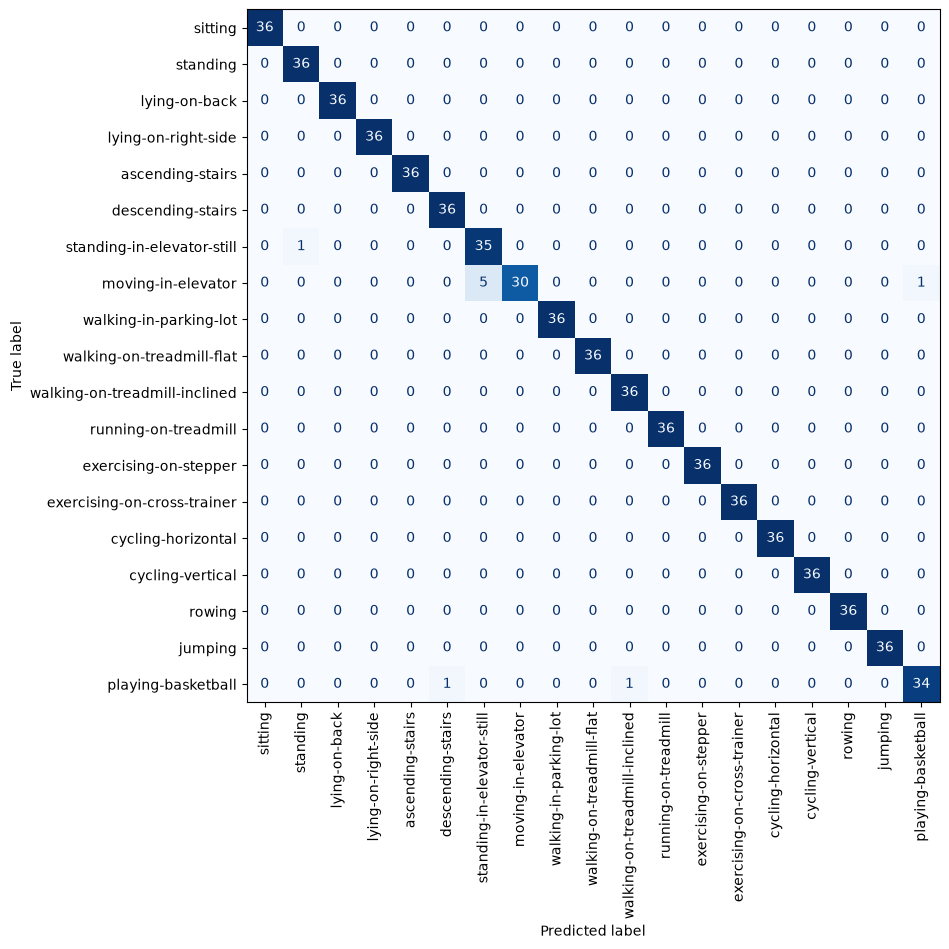

In [50]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
)

x_cage_val, y_cage_val = data_module.data_val
predictions_val = model_module._get_predictions(x_cage_val)
incorrect_val = (predictions_val != y_cage_val).astype(int)

print(f'validation samples : {len(x_cage_val)}')
print(f'accuracy           : {(predictions_val == y_cage_val).mean():.2%}')
print(f'misclassified      : {incorrect_val.sum()}')

cm = confusion_matrix(y_cage_val, predictions_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data_module.classes.values())
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax, colorbar=False)
plt.show()

In [29]:
def classifier_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }

def summarize_scenarios(name, flagged_test, incorrect_test, y_test, y_pred_test):
    """Print the abstain-scenario and review-scenario metric tables for one method."""
    total_errors = int(incorrect_test.sum())
    baseline_metrics = classifier_metrics(y_test, y_pred_test)

    kept = ~flagged_test
    kept_metrics = classifier_metrics(y_test[kept], y_pred_test[kept])
    caught_mask = flagged_test & (incorrect_test == 1)
    missed_mask = kept & (incorrect_test == 1)

    print(f'--- {name}: Scenario 1, abstain on what the cage flags ---')
    print(f'{"metric":<20}{"baseline":>15}{"cage-kept":>15}{"change":>15}')
    for metric_name in baseline_metrics:
        print(
            f'{metric_name:<20}{baseline_metrics[metric_name]:>15.4f}'
            f'{kept_metrics[metric_name]:>15.4f}'
            f'{kept_metrics[metric_name] - baseline_metrics[metric_name]:>+15.4f}'
        )
    print()
    print(f'sent for review : {int(flagged_test.sum())} of {len(y_test)}')
    print(f'errors caught   : {int(caught_mask.sum())} of {total_errors}')
    print(f'errors missed   : {int(missed_mask.sum())} of {total_errors}')
    print(f'coverage        : {kept.mean():.2%} ({int(kept.sum())} of {len(y_test)})')

    corrected_test = y_pred_test.copy()
    corrected_test[caught_mask] = y_test[caught_mask]
    corrected_metrics = classifier_metrics(y_test, corrected_test)

    print(f'\n--- {name}: Scenario 2, review everything flagged ---')
    print(f'{"metric":<20}{"baseline":>15}{"with review":>15}{"change":>15}')
    for metric_name in baseline_metrics:
        print(
            f'{metric_name:<20}{baseline_metrics[metric_name]:>15.4f}'
            f'{corrected_metrics[metric_name]:>15.4f}'
            f'{corrected_metrics[metric_name] - baseline_metrics[metric_name]:>+15.4f}'
        )

    return baseline_metrics, kept_metrics, corrected_metrics

## Detecting misclassifications

Two methods, side by side: **MSP**, which only reads the model's
output probabilities, and **SPARDACUS**, which reads the `relu`
activation captured above. Both are evaluated the same way: fit on
the cage's train split, a threshold chosen on its validation split
by maximizing MCC, then applied once to its held-out test split.

### MSP

The simplest cage: the largest class probability as a confidence
score, flagged below a threshold. No fitting, so `train_cage()` does
nothing.

Hendrycks & Gimpel (2016), https://arxiv.org/abs/1610.02136

In [30]:
from safetycage.methods.msp import MSP

msp = MSP(model_module=model_module, data_module=data_module)
msp.train_cage()

statistics_val = msp.predict(x_cage_val, predictions_val)
print(f'mean confidence, correct   : {statistics_val[incorrect_val == 0].mean():.4f}')
print(f'mean confidence, incorrect : {statistics_val[incorrect_val == 1].mean():.4f}')

mean confidence, correct   : 0.5299
mean confidence, incorrect : 0.2603


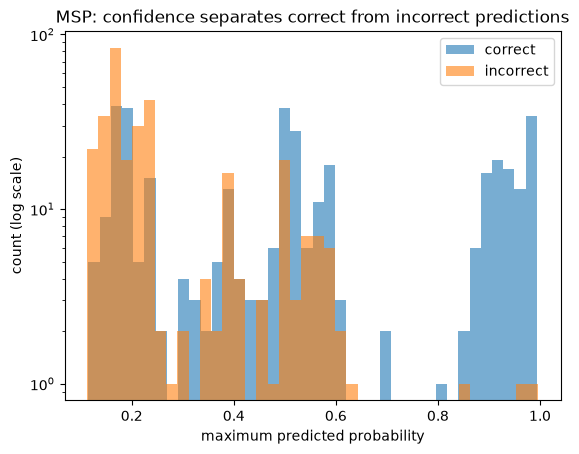

In [31]:
plt.hist(statistics_val[incorrect_val == 0], bins=40, alpha=0.6, label='correct')
plt.hist(statistics_val[incorrect_val == 1], bins=40, alpha=0.6, label='incorrect')
plt.yscale('log')
plt.xlabel('maximum predicted probability')
plt.ylabel('count (log scale)')
plt.title('MSP: confidence separates correct from incorrect predictions')
plt.legend()
plt.show()

In [32]:
from safetycage.utils.metrics import MCC

msp_result = msp.find_best_threshold(
    y_true=incorrect_val,
    y_probs=statistics_val,
    metric_fn=MCC,
    search='linear',
)
msp_threshold = msp_result['threshold_opt']

print(f"optimal threshold : {msp_threshold:.4f}")
print(f"MCC at threshold  : {float(msp_result['metric_max']):.4f}")

optimal threshold : 0.4169
MCC at threshold  : 0.4567


In [33]:
x_cage_test, y_cage_test = data_module.data_test
y_pred_test = model_module._get_predictions(x_cage_test)
incorrect_test = (y_pred_test != y_cage_test).astype(int)

msp_statistics_test = msp.predict(x_cage_test, y_pred_test)
msp_flagged_test = msp.flag(msp_statistics_test, msp_threshold)

msp_auroc = msp.auroc(y_true=incorrect_test, y_pred=msp_statistics_test)
msp_roc = msp.roc_curve(y_true=incorrect_test, y_pred=msp_statistics_test)

caught = int((msp_flagged_test & (incorrect_test == 1)).sum())
total_errors = int(incorrect_test.sum())

print(f'test samples           : {len(x_cage_test)}')
print(f'actually misclassified : {total_errors}')
print(f'flagged by the cage    : {int(msp_flagged_test.sum())}')
print(f'errors caught          : {caught} of {total_errors} ({caught / total_errors:.0%})')
print(f'AUROC                  : {msp_auroc:.4f}')

test samples           : 684
actually misclassified : 324
flagged by the cage    : 406
errors caught          : 268 of 324 (83%)
AUROC                  : 0.7770


In [34]:
msp_baseline_metrics, msp_kept_metrics, msp_corrected_metrics = summarize_scenarios(
    'MSP', msp_flagged_test, incorrect_test, y_cage_test, y_pred_test
)

--- MSP: Scenario 1, abstain on what the cage flags ---
metric                     baseline      cage-kept         change
accuracy                     0.5263         0.7986        +0.2722
precision (macro)            0.5524         0.6941        +0.1417
recall (macro)               0.5263         0.6439        +0.1176
f1 (macro)                   0.4610         0.6337        +0.1726
MCC                          0.5159         0.7782        +0.2622

sent for review : 406 of 684
errors caught   : 268 of 324
errors missed   : 56 of 324
coverage        : 40.64% (278 of 684)

--- MSP: Scenario 2, review everything flagged ---
metric                     baseline    with review         change
accuracy                     0.5263         0.9181        +0.3918
precision (macro)            0.5524         0.9318        +0.3794
recall (macro)               0.5263         0.9181        +0.3918
f1 (macro)                   0.4610         0.9151        +0.4540
MCC                          0.5159      

In [35]:
from utils import save_result, flatten_metrics

save_result(
    example='04-activity-monitor',
    method='MSP',
    threshold=float(msp_threshold),
    auroc=float(msp_auroc),
    test_samples=int(len(x_cage_test)),
    total_errors=total_errors,
    flagged=int(msp_flagged_test.sum()),
    errors_caught=caught,
    errors_missed=total_errors - caught,
    coverage=float((~msp_flagged_test).mean()),
    **flatten_metrics('baseline', msp_baseline_metrics),
    **flatten_metrics('cage_kept', msp_kept_metrics),
    **flatten_metrics('with_review', msp_corrected_metrics),
)

PosixPath('/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/examples/results.json')

### SPARDACUS

SPARDACUS learns, per class, a projection that separates the `relu`
activations of correctly- and incorrectly-classified training
samples, then scores new samples against both distributions as a
p-value. It needs *both* correct and incorrect examples for every
class to fit those distributions -- a class with too few of either
in the cage's train split is marked unreliable and its test samples
get a NaN statistic, filtered out below before scoring.

Johnsen & Remonato, https://proceedings.mlr.press/v265/johnsen25a.html

In [36]:
from safetycage.methods.spardacus import SPARDACUS

spardacus = SPARDACUS(
    model_module=model_module, data_module=data_module,
    s_statistic_source='incorrectly',
)
spardacus.train_cage()

spardacus_statistics_val = spardacus.predict(x_cage_val, predictions_val)
spardacus_statistics_val, incorrect_val_clean = spardacus.remove_nan_values(
    spardacus_statistics_val, incorrect_val
)

print(f'unreliable classes         : {sorted(spardacus.unreliable_classes) or "none"}')
print(f'mean p-value, correct      : {spardacus_statistics_val[incorrect_val_clean == 0].mean():.4f}')
print(f'mean p-value, incorrect    : {spardacus_statistics_val[incorrect_val_clean == 1].mean():.4f}')

  0%|          | 0/19 [00:00<?, ?it/s]/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src/safetycage/methods/spardacus.py:187: UserWarning: No incorrect and/or correct samples for class "sitting" exist in layer activations. This class will be flagged as unreliable and the results for this class are unreliable. We recommend using a different safetycage method or ensuring some incorrect and/or correct samples exist in this class.
  warnings.warn(f"No incorrect and/or correct samples for class \"{class_label}\" exist in layer activations. This class will be flagged as unreliable and the results "
/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src/safetycage/methods/spardacus.py:291: UserWarning: [Gaussian Mixture Model WARNING] There are not enough incorrect samples in the "standing" class to fit a Gaussian Mixture Model. Provided: 3. Minimum required: 10. We recommend that you use a different safetycage method.
  warn

unreliable classes         : ['exercising-on-cross-trainer', 'lying-on-back', 'moving-in-elevator', 'rowing', 'running-on-treadmill', 'sitting', 'standing', 'standing-in-elevator-still', 'walking-on-treadmill-inclined']
mean p-value, correct      : 0.0561
mean p-value, incorrect    : 0.0437



/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src/safetycage/methods/spardacus.py:430: UserWarning: The p-value for the classes {'exercising-on-cross-trainer', 'sitting', 'running-on-treadmill', 'moving-in-elevator', 'rowing', 'standing-in-elevator-still', 'standing', 'lying-on-back', 'walking-on-treadmill-inclined'} have been set to NaN due to insufficient data to fit the Gaussian Mixture Models. Consider using a different safetycage method.
  warnings.warn(f"The p-value for the classes {self.unreliable_classes} have been set to NaN due to insufficient data to fit the Gaussian Mixture Models. "


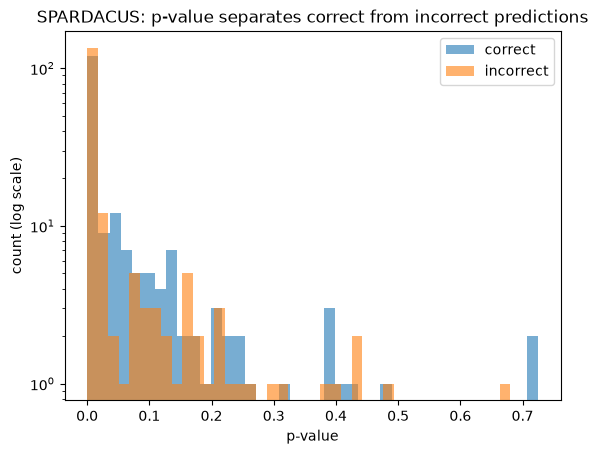

In [37]:
plt.hist(spardacus_statistics_val[incorrect_val_clean == 0], bins=40, alpha=0.6, label='correct')
plt.hist(spardacus_statistics_val[incorrect_val_clean == 1], bins=40, alpha=0.6, label='incorrect')
plt.yscale('log')
plt.xlabel('p-value')
plt.ylabel('count (log scale)')
plt.title('SPARDACUS: p-value separates correct from incorrect predictions')
plt.legend()
plt.show()

In [38]:
spardacus_result = spardacus.find_best_threshold(
    y_true=incorrect_val_clean,
    y_probs=spardacus_statistics_val,
    metric_fn=MCC,
    search='log',
)
spardacus_threshold = spardacus_result['threshold_opt']

print(f"optimal threshold : {spardacus_threshold:.6f}")
print(f"MCC at threshold  : {float(spardacus_result['metric_max']):.4f}")

optimal threshold : 0.428667
MCC at threshold  : 0.0215


In [39]:
spardacus_statistics_test_raw = spardacus.predict(x_cage_test, y_pred_test)
valid = ~np.isnan(spardacus_statistics_test_raw)

spardacus_statistics_test = spardacus_statistics_test_raw[valid]
spardacus_incorrect_test = incorrect_test[valid]
spardacus_y_test = y_cage_test[valid]
spardacus_y_pred_test = y_pred_test[valid]

spardacus_flagged_test = spardacus.flag(spardacus_statistics_test, spardacus_threshold)

spardacus_auroc = spardacus.auroc(y_true=spardacus_incorrect_test, y_pred=spardacus_statistics_test)
spardacus_roc = spardacus.roc_curve(y_true=spardacus_incorrect_test, y_pred=spardacus_statistics_test)

spardacus_caught = int((spardacus_flagged_test & (spardacus_incorrect_test == 1)).sum())
spardacus_total_errors = int(spardacus_incorrect_test.sum())

print(f'test samples (NaN-filtered) : {valid.sum()} of {len(x_cage_test)}')
print(f'actually misclassified      : {spardacus_total_errors}')
print(f'flagged by the cage         : {int(spardacus_flagged_test.sum())}')
print(f'errors caught                : {spardacus_caught} of {spardacus_total_errors} '
      f'({spardacus_caught / spardacus_total_errors:.0%})')
print(f'AUROC                        : {spardacus_auroc:.4f}')

test samples (NaN-filtered) : 368 of 684
actually misclassified      : 189
flagged by the cage         : 11
errors caught                : 6 of 189 (3%)
AUROC                        : 0.3489


/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src/safetycage/methods/spardacus.py:430: UserWarning: The p-value for the classes {'exercising-on-cross-trainer', 'sitting', 'running-on-treadmill', 'moving-in-elevator', 'rowing', 'standing-in-elevator-still', 'standing', 'lying-on-back', 'walking-on-treadmill-inclined'} have been set to NaN due to insufficient data to fit the Gaussian Mixture Models. Consider using a different safetycage method.
  warnings.warn(f"The p-value for the classes {self.unreliable_classes} have been set to NaN due to insufficient data to fit the Gaussian Mixture Models. "


In [40]:
spardacus_baseline_metrics, spardacus_kept_metrics, spardacus_corrected_metrics = summarize_scenarios(
    'SPARDACUS', spardacus_flagged_test, spardacus_incorrect_test, spardacus_y_test, spardacus_y_pred_test
)

--- SPARDACUS: Scenario 1, abstain on what the cage flags ---
metric                     baseline      cage-kept         change
accuracy                     0.4864         0.4874        +0.0010
precision (macro)            0.4177         0.4026        -0.0151
recall (macro)               0.4112         0.4130        +0.0018
f1 (macro)                   0.3825         0.3792        -0.0033
MCC                          0.4569         0.4609        +0.0041

sent for review : 11 of 368
errors caught   : 6 of 189
errors missed   : 183 of 189
coverage        : 97.01% (357 of 368)

--- SPARDACUS: Scenario 2, review everything flagged ---
metric                     baseline    with review         change
accuracy                     0.4864         0.5027        +0.0163
precision (macro)            0.4177         0.4425        +0.0249
recall (macro)               0.4112         0.4251        +0.0139
f1 (macro)                   0.3825         0.3982        +0.0157
MCC                          0.

In [41]:
save_result(
    example='04-activity-monitor',
    method='SPARDACUS',
    threshold=float(spardacus_threshold),
    auroc=float(spardacus_auroc),
    test_samples=int(valid.sum()),
    total_errors=spardacus_total_errors,
    flagged=int(spardacus_flagged_test.sum()),
    errors_caught=spardacus_caught,
    errors_missed=spardacus_total_errors - spardacus_caught,
    coverage=float((~spardacus_flagged_test).mean()),
    **flatten_metrics('baseline', spardacus_baseline_metrics),
    **flatten_metrics('cage_kept', spardacus_kept_metrics),
    **flatten_metrics('with_review', spardacus_corrected_metrics),
)

PosixPath('/Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/examples/results.json')

## MSP vs SPARDACUS

Both ROC curves on the same axes -- higher and further left is
better.

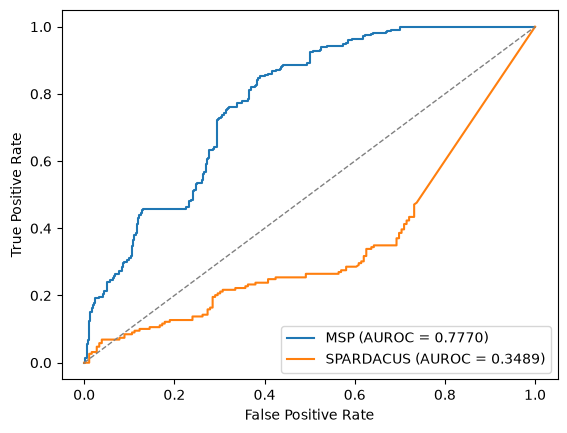

In [42]:
plt.plot(msp_roc['fpr'], msp_roc['tpr'], label=f'MSP (AUROC = {msp_auroc:.4f})')
plt.plot(spardacus_roc['fpr'], spardacus_roc['tpr'], label=f'SPARDACUS (AUROC = {spardacus_auroc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Where to go next

MSP works with any classifier that outputs probabilities, no
hidden-layer access required. SPARDACUS needs those activations
*and* a reasonable number of misclassifications in every class to
fit against -- a much stronger requirement, and one worth checking
before reaching for it on a new model. Mahalanobis and RED read
pre-activations `TorchModelModule` doesn't expose; wrapping this GRU
for either would mean writing a custom `ModelModule`, the way
`examples/01-mnist/mlp_modelmodule.py` and
`examples/03-cifar10-cnn/cnn_modelmodule.py` do.